# 03 - Feature Engineering (YPerf JO28)

Objectif: transformer le dataset olympique nettoye en un jeu de donnees supervise exploitable par un modele de prevision des medailles pour l'edition suivante (cible JO 2028).

On reutilise les modules du package `src/` pour garantir que la demarche du notebook et le pipeline de production restent strictement identiques (pas de code duplique).

## Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Rendre le package src importable depuis le dossier notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_prep import load_raw_data, clean_olympics_data, aggregate_country_year_sport
from src.features import add_temporal_features, make_supervised_target, build_supervised_dataset
from src.config import TARGET_COL, RAW_DATA_PATH, SUPERVISED_DATA_PATH
pd.set_option('display.max_columns', 40)
print('TARGET_COL =', TARGET_COL)

TARGET_COL = medals_next_edition


## 1) Du brut a la granularite pays / annee / sport

Les donnees brutes sont au niveau athlete-epreuve. Pour predire un nombre de medailles, on agrege a la maille **(NOC, Year, Sport)**. Le comptage des medailles deduplique les epreuves par equipe (une medaille d'equipe = 1 medaille, pas une par athlete).

In [2]:
raw = clean_olympics_data(load_raw_data(RAW_DATA_PATH))
analytics = aggregate_country_year_sport(raw)
print('lignes brutes nettoyees:', len(raw))
print('lignes agregees (NOC, Year, Sport):', len(analytics))
analytics.head()

lignes brutes nettoyees: 252565
lignes agregees (NOC, Year, Sport): 26229


,Year,NOC,Sport,athletes,entries,female_ratio,male_ratio,medals,medal_points
0,1896,AUS,Athletics,1,3,0.0,1.0,2,6
1,1896,AUS,Tennis,1,2,0.0,1.0,1,1
2,1896,AUT,Cycling,1,4,0.0,1.0,3,5
3,1896,AUT,Fencing,1,1,0.0,1.0,0,0
4,1896,AUT,Swimming,2,3,0.0,1.0,2,5


## 2) Features temporelles (lags & moyennes glissantes)

La performance d'un pays dans un sport est fortement auto-correlee dans le temps. On construit donc, **par groupe (NOC, Sport)** et dans l'ordre chronologique:

- `medals_lag_1`, `medals_lag_2`: medailles des 1 et 2 editions precedentes
- `medals_roll_3`: moyenne glissante des 3 editions precedentes
- lags equivalents pour points, engagements, athletes et ratio femmes

Point cle **anti-fuite de donnees**: chaque feature n'utilise que le passe (`shift(1)`), jamais l'edition courante ni future.

In [3]:
featured = add_temporal_features(analytics)
lag_cols = ['NOC','Sport','Year','medals','medals_lag_1','medals_lag_2','medals_roll_3']
featured[featured['NOC'].eq('USA') & featured['Sport'].eq('Swimming')][lag_cols].tail(8)

,NOC,Sport,Year,medals,medals_lag_1,medals_lag_2,medals_roll_3
25282,USA,Swimming,1996,26,27.0,18.0,26.000000
25283,USA,Swimming,2000,31,26.0,27.0,23.666667
25284,USA,Swimming,2004,28,31.0,26.0,28.000000
25285,USA,Swimming,2008,31,28.0,31.0,28.333333
25286,USA,Swimming,2012,31,31.0,28.0,30.000000
25287,USA,Swimming,2016,33,31.0,31.0,30.000000
25288,USA,Swimming,2020,30,33.0,31.0,31.666667
25289,USA,Swimming,2024,27,30.0,33.0,31.333333


## 3) Definition de la cible: medailles de l'edition suivante

La cible `medals_next_edition` est le nombre de medailles du **meme (NOC, Sport) a l'edition suivante** (`shift(-1)`). C'est ce qui transforme le probleme en apprentissage supervise de type regression.

In [4]:
supervised_full = make_supervised_target(featured)
chk = supervised_full[supervised_full['NOC'].eq('FRA') & supervised_full['Sport'].eq('Athletics')]
chk[['Year','medals', TARGET_COL]].tail(6)

,Year,medals,medals_next_edition
8389,2004,2,2.0
8390,2008,2,3.0
8391,2012,3,6.0
8392,2016,6,1.0
8393,2020,1,1.0
8394,2024,1,NaN


## 4) Jeu supervise final

On retire les lignes ou la cible est inconnue (derniere edition de chaque groupe: pas de 'suivante' observee). Ces lignes restent utiles plus tard pour l'inference 2028, mais pas pour l'entrainement.

In [5]:
supervised = build_supervised_dataset(supervised_full)
print('lignes entrainables:', len(supervised))
print('editions couvertes:', sorted(supervised['Year'].unique())[:5], '...', sorted(supervised['Year'].unique())[-3:])
supervised[TARGET_COL].describe()

lignes entrainables: 22036
editions couvertes: [np.int64(1896), np.int64(1900), np.int64(1904), np.int64(1906), np.int64(1908)] ... [np.int64(2012), np.int64(2016), np.int64(2020)]


count    22036.000000
mean         0.754266
std          2.286992
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         65.000000
Name: medals_next_edition, dtype: float64

## 5) Controle qualite de la cible

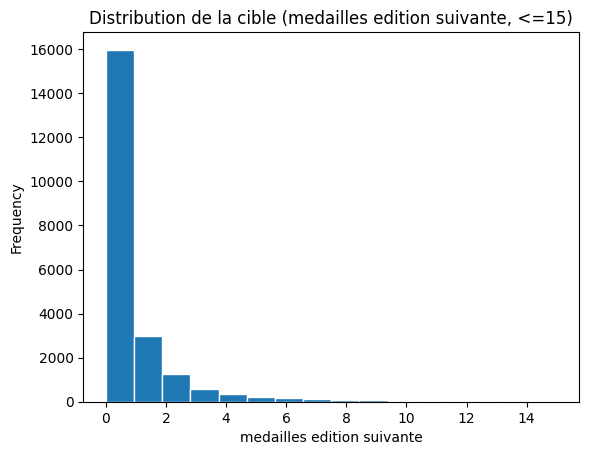

In [6]:
import matplotlib.pyplot as plt
ax = supervised[supervised[TARGET_COL] <= 15][TARGET_COL].plot(kind='hist', bins=16, edgecolor='white')
ax.set_title('Distribution de la cible (medailles edition suivante, <=15)')
ax.set_xlabel('medailles edition suivante')
plt.show()

## 6) Export

On sauvegarde le jeu supervise pour le notebook de modelisation (04). Le pipeline de production `python -m src.pipeline` produit exactement le meme fichier.

In [7]:
Path(SUPERVISED_DATA_PATH).parent.mkdir(parents=True, exist_ok=True)
supervised.to_csv(SUPERVISED_DATA_PATH, index=False)
print('ecrit:', SUPERVISED_DATA_PATH)

ecrit: /Users/alx/Ynov/B3/Projet-Fil-Rouge-JO28/data/processed/supervised_country_year_sport.csv


### Synthese

- Maille d'analyse: **(NOC, Year, Sport)**.
- Features **strictement passees** (lags + rolling) pour eviter toute fuite temporelle.
- Cible de regression: **medailles de l'edition suivante**.
- Le jeu supervise est pret pour l'entrainement et l'evaluation temporelle (notebook 04).